In [6]:
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
import h5py
import json
import sys
from PIL import Image
from datetime import datetime

# Go up TWO levels: month2 -> notebooks -> project root
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "../..")))

from src.convert_videos_to_events import (
    VideoToEventConverter,
    convert_video_to_events,
    batch_convert
)

In [11]:
def load_events(h5_path):
    with h5py.File(h5_path, 'r') as f:
        events = {
            't': f['events/t'][:],
            'x': f['events/x'][:],
            'y': f['events/y'][:],
            'p': f['events/p'][:],
        }
        height = f.attrs['height']
        width = f.attrs['width']
    return events, height, width



In [14]:
def plot_event_scatter(events, max_events=50000):
    idx = np.random.choice(len(events['t']), 
                           min(max_events, len(events['t'])), 
                           replace=False)

    on_mask = events['p'][idx] == 1
    off_mask = events['p'][idx] == 0

    plt.figure(figsize=(6, 4))
    plt.scatter(events['x'][idx][on_mask],
                events['y'][idx][on_mask],
                s=1, c='red', label='ON')
    plt.scatter(events['x'][idx][off_mask],
                events['y'][idx][off_mask],
                s=1, c='blue', label='OFF')

    plt.gca().invert_yaxis()
    plt.title("Event spatial distribution")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.legend(markerscale=5)
    plt.show()


Loaded 499,984 events from events.npy
Event fields: ('t', 'x', 'y', 'p')


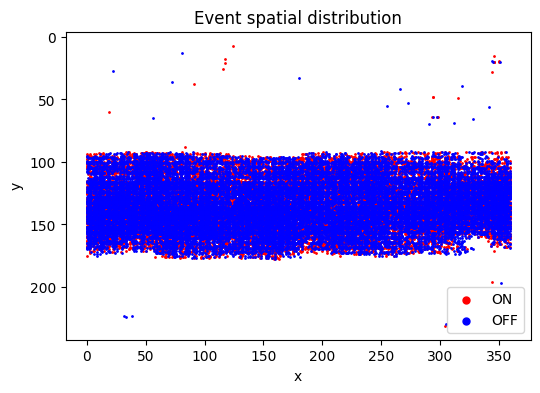

In [29]:
# Load events from previously converted Train001
events_path = PROJECT_ROOT / "events" / "train" / "Train003" / "events.npy"
events = np.load(events_path)

print(f"Loaded {len(events):,} events from {events_path.name}")
print(f"Event fields: {events.dtype.names}")

# Visualize
plot_event_scatter(events)

In [37]:
print(events.shape)
print(events.dtype)
print(events[:50])

(499984,)
[('t', '<i8'), ('x', '<i8'), ('y', '<i8'), ('p', 'u1')]
[(0,  59, 92, 1) (0,  60, 92, 1) (0, 244, 92, 1) (0,  60, 93, 1)
 (0,  61, 93, 1) (0, 184, 93, 1) (0,  60, 94, 1) (0,  61, 94, 1)
 (0,  92, 94, 1) (0,  94, 94, 1) (0, 124, 94, 1) (0, 183, 94, 1)
 (0, 184, 94, 1) (0,  61, 95, 1) (0,  62, 95, 1) (0,  89, 95, 1)
 (0,  94, 95, 1) (0,  95, 95, 1) (0, 124, 95, 1) (0, 125, 95, 1)
 (0, 183, 95, 1) (0, 184, 95, 1) (0,  62, 96, 1) (0,  94, 96, 1)
 (0,  95, 96, 1) (0, 125, 96, 1) (0, 126, 96, 1) (0, 142, 96, 1)
 (0,  62, 97, 1) (0,  63, 97, 1) (0,  91, 97, 1) (0, 140, 97, 1)
 (0, 141, 97, 1) (0, 167, 97, 1) (0, 183, 97, 1) (0,  62, 98, 1)
 (0,  63, 98, 1) (0,  64, 98, 1) (0,  91, 98, 1) (0, 130, 98, 1)
 (0, 167, 98, 1) (0, 182, 98, 1) (0,  63, 99, 1) (0,  64, 99, 1)
 (0,  91, 99, 1) (0, 126, 99, 1) (0, 127, 99, 1) (0, 130, 99, 1)
 (0, 142, 99, 1) (0, 143, 99, 1)]


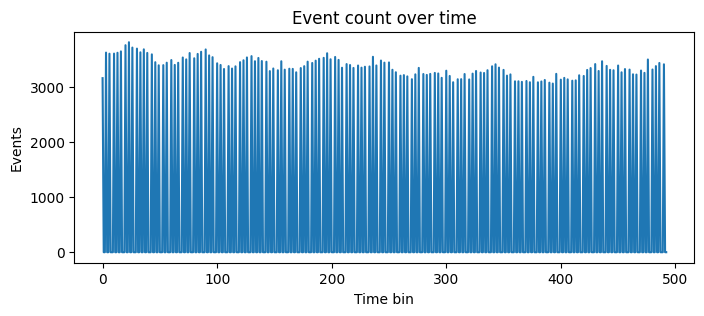

In [30]:
def plot_event_timeline(events, bin_us=10000):
    t = events['t']
    bins = np.arange(t.min(), t.max(), bin_us)
    hist, _ = np.histogram(t, bins)

    plt.figure(figsize=(8, 3))
    plt.plot(hist)
    plt.title("Event count over time")
    plt.xlabel("Time bin")
    plt.ylabel("Events")
    plt.show()

plot_event_timeline(events)


In [31]:
def events_to_frame(events, H, W, t_start, t_end):
    mask = (events['t'] >= t_start) & (events['t'] < t_end)
    
    frame = np.zeros((H, W), dtype=np.int32)
    xs = events['x'][mask]
    ys = events['y'][mask]
    ps = events['p'][mask]

    frame[ys, xs] += np.where(ps == 1, 1, -1)
    return frame


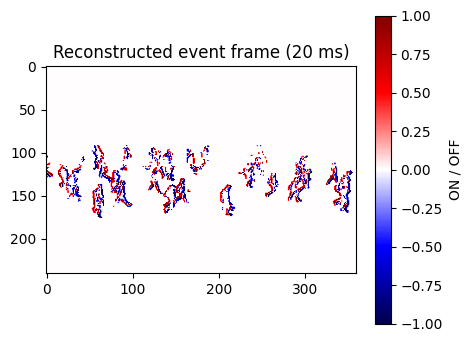

In [32]:
# Get dimensions from h5 file or use known resolution
H, W = 240, 360  # UCSDped2 resolution

t0 = events['t'][0]
frame = events_to_frame(events, H, W, t0, t0 + 20000)

plt.figure(figsize=(5, 4))
plt.imshow(frame, cmap='seismic')
plt.colorbar(label='ON / OFF')
plt.title("Reconstructed event frame (20 ms)")
plt.show()

In [33]:
def polarity_frame(events, H, W, polarity=1, t_start=None, t_end=None):
    if t_start is None:
        t_start = events['t'].min()
    if t_end is None:
        t_end = events['t'].max()

    mask = (
        (events['p'] == polarity) &
        (events['t'] >= t_start) &
        (events['t'] < t_end)
    )

    frame = np.zeros((H, W))
    frame[events['y'][mask], events['x'][mask]] = 1
    return frame


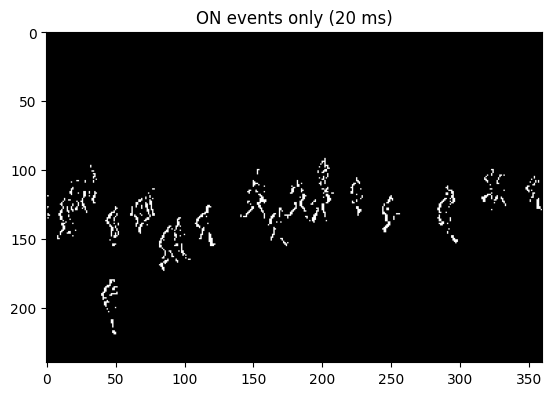

In [28]:
on_frame = polarity_frame(events, H, W, polarity=1,
                          t_start=t0, t_end=t0+20000)

plt.imshow(on_frame, cmap='gray')
plt.title("ON events only (20 ms)")
plt.show()
